# **Task 64: CNN on CIFAR-10 Dataset**

**Student Name:** Qalb E Zahra Mashhadi  
**Program:** NAVTTC — Artificial Intelligence (ML & DL)  

---

## **1. Objective**

The objective of this task is to **train a CNN model on a real-world image dataset (CIFAR-10)**.  
CIFAR-10 contains **60,000 color (RGB) images** categorized into **10 different classes** (Airplanes, Cars, Birds, Cats, etc.).  

---

## **2. Learning Outcomes**

* **Data Normalization:** Learned why converting image pixels from **0-255 to decimal range (0-1)** is crucial for **faster neural network training**.  

* **Architecture Design:** Built an **effective CNN model** for feature extraction and classification, including:  
  - **Conv2D Layer:** Detects patterns in images (edges, textures).  
  - **MaxPooling Layer:** Reduces image width and height to retain only **important features**.  
  - **Dense Layer:** Used for **final prediction**.  

* **Hyperparameter Tuning:** Learned how to adjust **number of filters** and use **dropout layers** to improve model accuracy and prevent overfitting.  

* **Multi-class Classification:** Learned how **Softmax activation** helps predict the correct category among **10 classes**.  

---

## **3. Conclusion**

Implementing CNN on CIFAR-10 helped us understand the **real challenges in computer vision**.  
Building a model is **not enough**; monitoring **accuracy and loss during training** is crucial.  
This task lays the **foundation for image recognition projects**, such as **automatic number plate recognition** or **face detection**.  

In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

In [2]:
# --- 1. Load and Preprocess Data ---

(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Normalize pixel values to be between 0 and 1

train_images, test_images = train_images / 255.0, test_images / 255.0

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

In [3]:
from tensorflow.keras.layers import Input

# --- 2. Build the CNN Model (Warning-Free Version) ---

model = models.Sequential([
    
    # Step 1: Define Input layer separately

    Input(shape=(32, 32, 3)),
    
    # First Convolutional Block (Now without input_shape argument)
    
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Second Convolutional Block
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Third Convolutional Block
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    
    # Classification Layers
    
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10)
])

In [4]:
# --- 3. Compile the Model ---

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [5]:
# --- 4. Training ---

print("Training CNN on CIFAR-10...")

history = model.fit(train_images, train_labels, epochs=10, 
                    validation_data=(test_images, test_labels))

Training CNN on CIFAR-10...
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 17ms/step - accuracy: 0.4258 - loss: 1.5642 - val_accuracy: 0.5394 - val_loss: 1.2803
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 26s 16ms/step - accuracy: 0.5715 - loss: 1.2088 - val_accuracy: 0.5781 - val_loss: 1.1720
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.6271 - loss: 1.0568 - val_accuracy: 0.6364 - val_loss: 1.0252
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.6659 - loss: 0.9488 - val_accuracy: 0.6620 - val_loss: 0.9722
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.6900 - loss: 0.8809 - val_accuracy: 0.6589 - val_loss: 0.9893
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.7111 - loss: 0.8269 - val_accuracy: 0.6746 - val_loss: 0.9354
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - accuracy: 0.7258 - loss: 0.7795 - val_accuracy: 0.6949 - val_loss: 0.8859
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 23

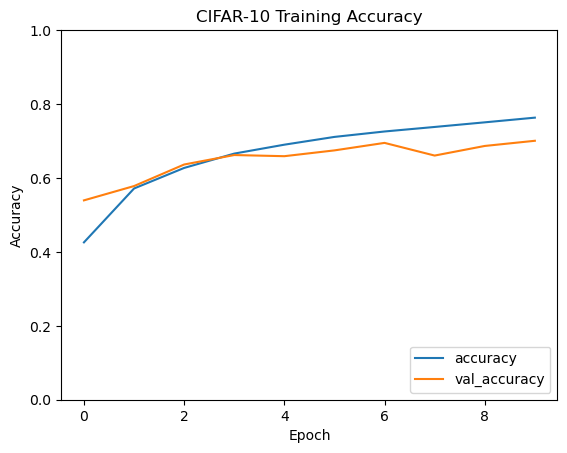

313/313 - 2s - 7ms/step - accuracy: 0.7006 - loss: 0.8869
Test Accuracy: 70.06%


In [6]:
# --- 5. Evaluation & Visualization ---

plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.title('CIFAR-10 Training Accuracy')
plt.show()

test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)
print(f'Test Accuracy: {test_acc*100:.2f}%')